# Part 2: Binary Classification (Cats vs. Dogs) 🐱🐶

Welcome to the second module of the course!

In the previous module, we solved a **Regression** problem (predicting housing prices). The output was a continuous number (e.g., $450,000).

Now, we tackle **Classification**. We want the neural network to answer a Yes/No question:
> **"Is this image a Dog?"**

We will implement and compare **two different mathematical approaches** to solve this on the same dataset:

1.  **The Probabilistic Approach:** Using `Sigmoid` activation and `Binary Cross Entropy` loss.
2.  **The Symmetric Approach:** Using `Tanh` activation and `Mean Squared Error` loss.

**The Data:**
We will train on the **Oxford-IIIT Pet Dataset** (high-quality images of pets). 
At the very end, we will run a "Stress Test" using the **CIFAR-10** dataset to see if our model can recognize cats and dogs from a completely different source (Generalization).

**Image Format:**
We will use **RGB Color Images** resized to $32 \times 32$ pixels. 
Input size: $32 \times 32 \times 3 = 3072$ values.

---

## 🧠 Theory Deep Dive: MSE vs. BCE

Before coding, let's understand the math. Why do we usually switch loss functions when moving from Regression to Classification?

### 1. Mean Squared Error (MSE)
$$ Loss = (y - \hat{y})^2 $$
* **Best for:** Regression (predicting temperature, prices).
* **How it works:** It measures geometric distance. It creates a parabola (bowl shape).
* **Problem with Classification:** If we use MSE with a probability output (Sigmoid), the curve becomes "non-convex" (wavy). This means Gradient Descent can get stuck in local minima. Also, if the model is "confidently wrong" (predicts 1.0 when true is 0.0), the gradient (slope) becomes very small, so learning stops. 
* **Exception:** MSE **CAN** be used effectively if we treat classification as a physics problem (predicting -1 vs +1) using **Tanh**, as we will see in Approach B.

### 2. Binary Cross Entropy (BCE)
$$ Loss = -[y \cdot \log(\hat{y}) + (1-y) \cdot \log(1-\hat{y})] $$
* **Best for:** Probabilistic Classification (0 to 1).
* **How it works:** It uses Information Theory (Logarithms).
* **Why it's better for Probabilities:**
    * If the model predicts $0.01$ (confident it's a Cat) but it's actually a Dog ($1.0$), the term $\log(0.01)$ becomes a huge negative number.
    * This creates a **massive penalty** (infinite gradient) for being "confidently wrong".
    * This forces the model to learn much faster than MSE when it makes big mistakes.

### Comparison of Approaches

| Feature | **Approach A (Probabilistic)** | **Approach B (Symmetric)** |
| :--- | :--- | :--- |
| **Activation** | **Sigmoid** $\sigma(x)$ | **Tanh** $\tanh(x)$ |
| **Output Range** | $0$ to $1$ | $-1$ to $+1$ |
| **Interpretation** | Probability (0% to 100%) | Polarity (Cat $\leftrightarrow$ Dog) |
| **Loss Function** | Binary Cross Entropy (BCE) | Mean Squared Error (MSE) |
| **Label for Cat** | $0.0$ | $-1.0$ |
| **Label for Dog** | $1.0$ | $+1.0$ |

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Check Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cpu


## 1. Data Preparation: Oxford-IIIT Pet

We will use the **Oxford-IIIT Pet** dataset. It contains 37 breeds of cats and dogs.
We need to process this data:

1.  **Resize:** The images are naturally large. We resize them to **32x32** pixels.
2.  **Color:** We keep the **3 RGB channels** (Red, Green, Blue).
3.  **Label Mapping:** The dataset gives us Breed IDs (0-36). We need to convert these to **Binary Labels** (Cat or Dog).

In [5]:
# 1. Define Transforms
# Input vector size will be 32 * 32 * 3 = 3072
transform = transforms.Compose([
    transforms.Resize((32, 32)),                     # Resize to 32x32
    transforms.ToTensor(),                           # [0, 255] -> [0.0, 1.0]
    # Normalize 3 channels: (mean_R, mean_G, mean_B), (std_R, std_G, std_B)
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) 
])

# 2. Load Oxford Pets
print("⏳ Loading Oxford-IIIT Pet Dataset...")
# Note: We rely on the fact that you already have the data in ./Datasets/oxford-iiit-pet
try:
    full_dataset = torchvision.datasets.OxfordIIITPet(root='../Datasets', split='trainval', download=True, transform=transform)
except RuntimeError:
    full_dataset = torchvision.datasets.OxfordIIITPet(root='../Datasets', split='trainval', download=True, transform=transform)

# 3. Create a Custom Binary Wrapper
# Oxford Pets has 37 classes. We need to map breeds to 0 (Cat) or 1 (Dog).
cat_breeds = [
    'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair', 'Egyptian Mau', 
    'Maine Coon', 'Persian', 'Ragdoll', 'Russian Blue', 'Siamese', 'Sphynx'
]

class BinaryOxfordPets(torch.utils.data.Dataset):
    def __init__(self, original_dataset):
        self.dataset = original_dataset
        self.classes = original_dataset.classes
        # Map class index to 0 (Cat) or 1 (Dog)
        self.label_map = {}
        for i, breed_name in enumerate(self.classes):
            # Usually Oxford Pet breeds are formatted like 'Abyssinian', 'yorkshire_terrier'
            # We check if the breed name contains any of the known cat breeds
            is_cat = any(cat in breed_name for cat in cat_breeds)
            self.label_map[i] = 0 if is_cat else 1

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, breed_label = self.dataset[idx]
        binary_label = self.label_map[breed_label]
        return img, binary_label

# Wrap the dataset
binary_dataset = BinaryOxfordPets(full_dataset)

# 4. Data Loader
train_loader = torch.utils.data.DataLoader(binary_dataset, batch_size=64, shuffle=True)

print(f"✅ Dataset Ready.")
print(f"   Total Images: {len(binary_dataset)}")
print(f"   Input Shape:  32x32x3 (RGB)")

⏳ Loading Oxford-IIIT Pet Dataset...
✅ Dataset Ready.
   Total Images: 3680
   Input Shape:  32x32x3 (RGB)


## 2. Visualizing Activation Functions

Before building models, let's see how the "decision making" layer differs.

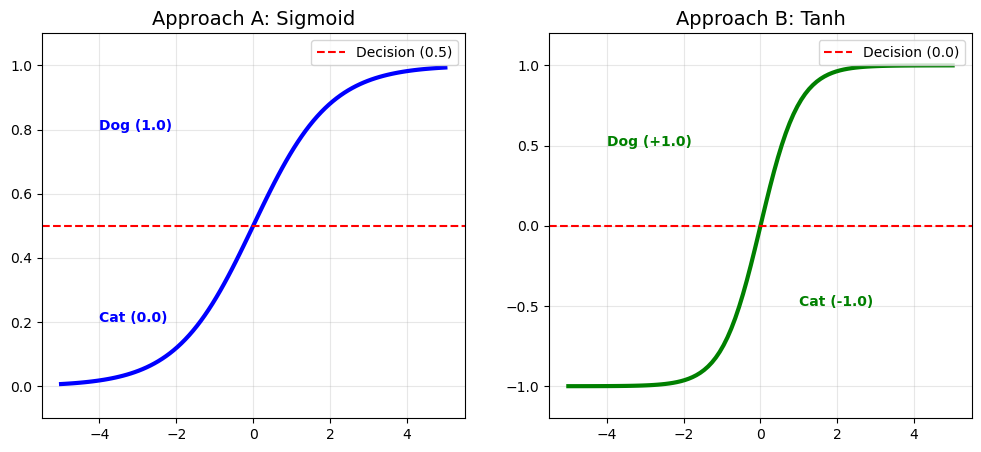

In [3]:
z = np.linspace(-5, 5, 100)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)

plt.figure(figsize=(12, 5))

# Plot 1: Sigmoid
plt.subplot(1, 2, 1)
plt.plot(z, sigmoid, 'b-', linewidth=3)
plt.title("Approach A: Sigmoid", fontsize=14)
plt.axhline(0.5, color='red', linestyle='--', label='Decision (0.5)')
plt.text(-4, 0.8, "Dog (1.0)", color='blue', fontweight='bold')
plt.text(-4, 0.2, "Cat (0.0)", color='blue', fontweight='bold')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Tanh
plt.subplot(1, 2, 2)
plt.plot(z, tanh, 'g-', linewidth=3)
plt.title("Approach B: Tanh", fontsize=14)
plt.axhline(0.0, color='red', linestyle='--', label='Decision (0.0)')
plt.text(-4, 0.5, "Dog (+1.0)", color='green', fontweight='bold')
plt.text(1, -0.5, "Cat (-1.0)", color='green', fontweight='bold')
plt.ylim(-1.2, 1.2)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

--- 
# Approach A: The Probabilistic Method (Sigmoid + BCE)

This is the standard industry approach for classification.

* **Model:** Outputs a probability $(0 	o 1)$.
* **Loss:** `BCELoss` (Penalizes the "surprise" logarithmically).
* **Labels:** We must map Cat to `0.0` and Dog to `1.0`.

In [4]:
class SigmoidNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()          
        # Input is 32*32*3 = 3072
        self.fc1 = nn.Linear(32*32*3, 256)      
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 1)          # Output Layer (1 Neuron)
        self.sigmoid = nn.Sigmoid()           # Squash to 0..1

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return self.sigmoid(x)

# Initialize
model_A = SigmoidNet().to(device)
optimizer_A = optim.Adam(model_A.parameters(), lr=0.001)
criterion_A = nn.BCELoss() 

print("🚀 Training Model A (Sigmoid)...")
losses_A = []

for epoch in range(5): 
    epoch_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        
        # --- LABEL MAPPING (Cat=0, Dog=1) ---
        # The loader already returns 0 or 1. We just need to convert to Float.
        targets = labels.float().unsqueeze(1).to(device)
        
        optimizer_A.zero_grad()
        outputs = model_A(images)
        loss = criterion_A(outputs, targets)
        loss.backward()
        optimizer_A.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    losses_A.append(avg_loss)
    print(f"Epoch {epoch+1} | BCE Loss: {avg_loss:.4f}")

🚀 Training Model A (Sigmoid)...
Epoch 1 | BCE Loss: 0.6901
Epoch 2 | BCE Loss: 0.5976
Epoch 3 | BCE Loss: 0.5660
Epoch 4 | BCE Loss: 0.5495
Epoch 5 | BCE Loss: 0.5122


--- 
# Approach B: The Symmetric Method (Tanh + MSE)

This approach treats classification like a "Physics" problem (Polarity).

* **Model:** Outputs a polarity $(-1 	o 1)$.
* **Loss:** `MSELoss` (Calculates geometric distance).
* **Labels:** We must map Cat to `-1.0` and Dog to `+1.0`.

In [9]:
class TanhNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        # Input is 32*32*3 = 3072
        self.fc1 = nn.Linear(32*32*3, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 1)
        self.tanh = nn.Tanh()                # Squash to -1..1

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return self.tanh(x)

model_B = TanhNet().to(device)
optimizer_B = optim.Adam(model_B.parameters(), lr=0.001)
criterion_B = nn.MSELoss() 

print("🚀 Training Model B (Tanh)...")
losses_B = []

for epoch in range(5):
    epoch_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        
        # --- LABEL MAPPING (Cat=-1, Dog=+1) ---
        # torch.where(condition, if_true, if_false)
        targets = torch.where(labels == 1, 1.0, -1.0).float().unsqueeze(1).to(device)
        
        optimizer_B.zero_grad()
        outputs = model_B(images)
        loss = criterion_B(outputs, targets)
        loss.backward()
        optimizer_B.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    losses_B.append(avg_loss)
    print(f"Epoch {epoch+1} | MSE Loss: {avg_loss:.4f}")

🚀 Training Model B (Tanh)...
Epoch 1 | MSE Loss: 1.1087
Epoch 2 | MSE Loss: 0.8991
Epoch 3 | MSE Loss: 0.7904
Epoch 4 | MSE Loss: 0.7295
Epoch 5 | MSE Loss: 0.6767


## 3. Comparison of Training Curves

Note that the loss values are on different scales, but we can see the convergence trends.

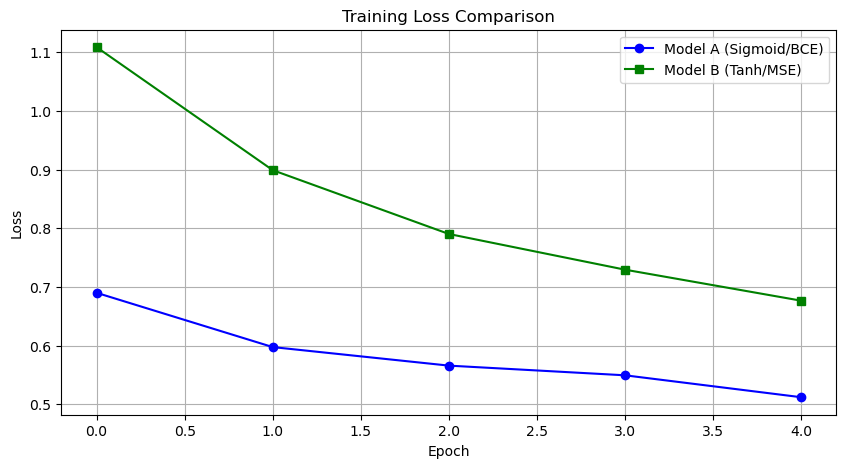

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(losses_A, label='Model A (Sigmoid/BCE)', marker='o', color='blue')
plt.plot(losses_B, label='Model B (Tanh/MSE)', marker='s', color='green')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

## 4. Final Showdown: Quantitative Comparison 📊

We trained on **Oxford Pets**. Now we test on **CIFAR-10**.

This is a **Generalization Test**. If the models work here, they have truly learned the concept of "Dog" and "Cat", rather than just memorizing the Oxford dataset.

Let's run through the **entire** CIFAR-10 test subset (~2000 images) and calculate the total accuracy for both models.

In [15]:
# 1. Load Independent Test Data (CIFAR-10)
# Must match the training transform (32x32, RGB)
cifar_transform = transforms.Compose([
    transforms.Resize((32, 32)),                    
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

try:
    cifar_set = torchvision.datasets.CIFAR10(root='../Datasets', train=False, download=True, transform=cifar_transform)
except RuntimeError:
    cifar_set = torchvision.datasets.CIFAR10(root='../Datasets', train=False, download=True, transform=cifar_transform)

# Filter CIFAR for Cats (3) and Dogs (5)
indices = [i for i, label in enumerate(cifar_set.targets) if label in [3, 5]]
cifar_subset = torch.utils.data.Subset(cifar_set, indices)

# Create two loaders:
# A. Large batch for fast calculation of Total Accuracy
full_loader = torch.utils.data.DataLoader(cifar_subset, batch_size=128, shuffle=False)
# B. Small batch for Visualization (next step)
vis_loader = torch.utils.data.DataLoader(cifar_subset, batch_size=10, shuffle=True)

# --- FULL EVALUATION LOOP ---
model_A.eval()
model_B.eval()

correct_A = 0
correct_B = 0
total = 0

print(f"🔍 Evaluating on {len(cifar_subset)} CIFAR-10 images...")

with torch.no_grad():
    for images, labels in full_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Ground Truth Logic: Is it a Dog?
        # In CIFAR: 5 is Dog. We create a boolean tensor: True if Dog, False if Cat.
        is_dog = (labels == 5)
        
        # --- Model A (Sigmoid) ---
        # Output 0..1. Prediction is Dog if > 0.5
        out_A = model_A(images)
        pred_A_is_dog = (out_A > 0.5).squeeze() # Boolean tensor
        correct_A += (pred_A_is_dog == is_dog).sum().item()
        
        # --- Model B (Tanh) ---
        # Output -1..1. Prediction is Dog if > 0.0
        out_B = model_B(images)
        pred_B_is_dog = (out_B > 0.0).squeeze() # Boolean tensor
        correct_B += (pred_B_is_dog == is_dog).sum().item()
        
        total += labels.size(0)

acc_A = 100 * correct_A / total
acc_B = 100 * correct_B / total

print(f"\n🏆 Final Accuracy on CIFAR-10 (Generalization Test):")
print(f"   Model A (Sigmoid): {acc_A:.2f}%")
print(f"   Model B (Tanh):    {acc_B:.2f}%")

Files already downloaded and verified
🔍 Evaluating on 2000 CIFAR-10 images...

🏆 Final Accuracy on CIFAR-10 (Generalization Test):
   Model A (Sigmoid): 51.85%
   Model B (Tanh):    52.50%


## 5. Visual Inspection (10 Random Images) 📸

Accuracy tells us *how many* the model got right, but visualization tells us *what* it is seeing.

Let's look at 10 random examples and compare the confidence of Model A vs. Model B.

C:\Users\jom_j\AppData\Local\Temp\ipykernel_11508\230729917.py:52: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\jom_j\anaconda3\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


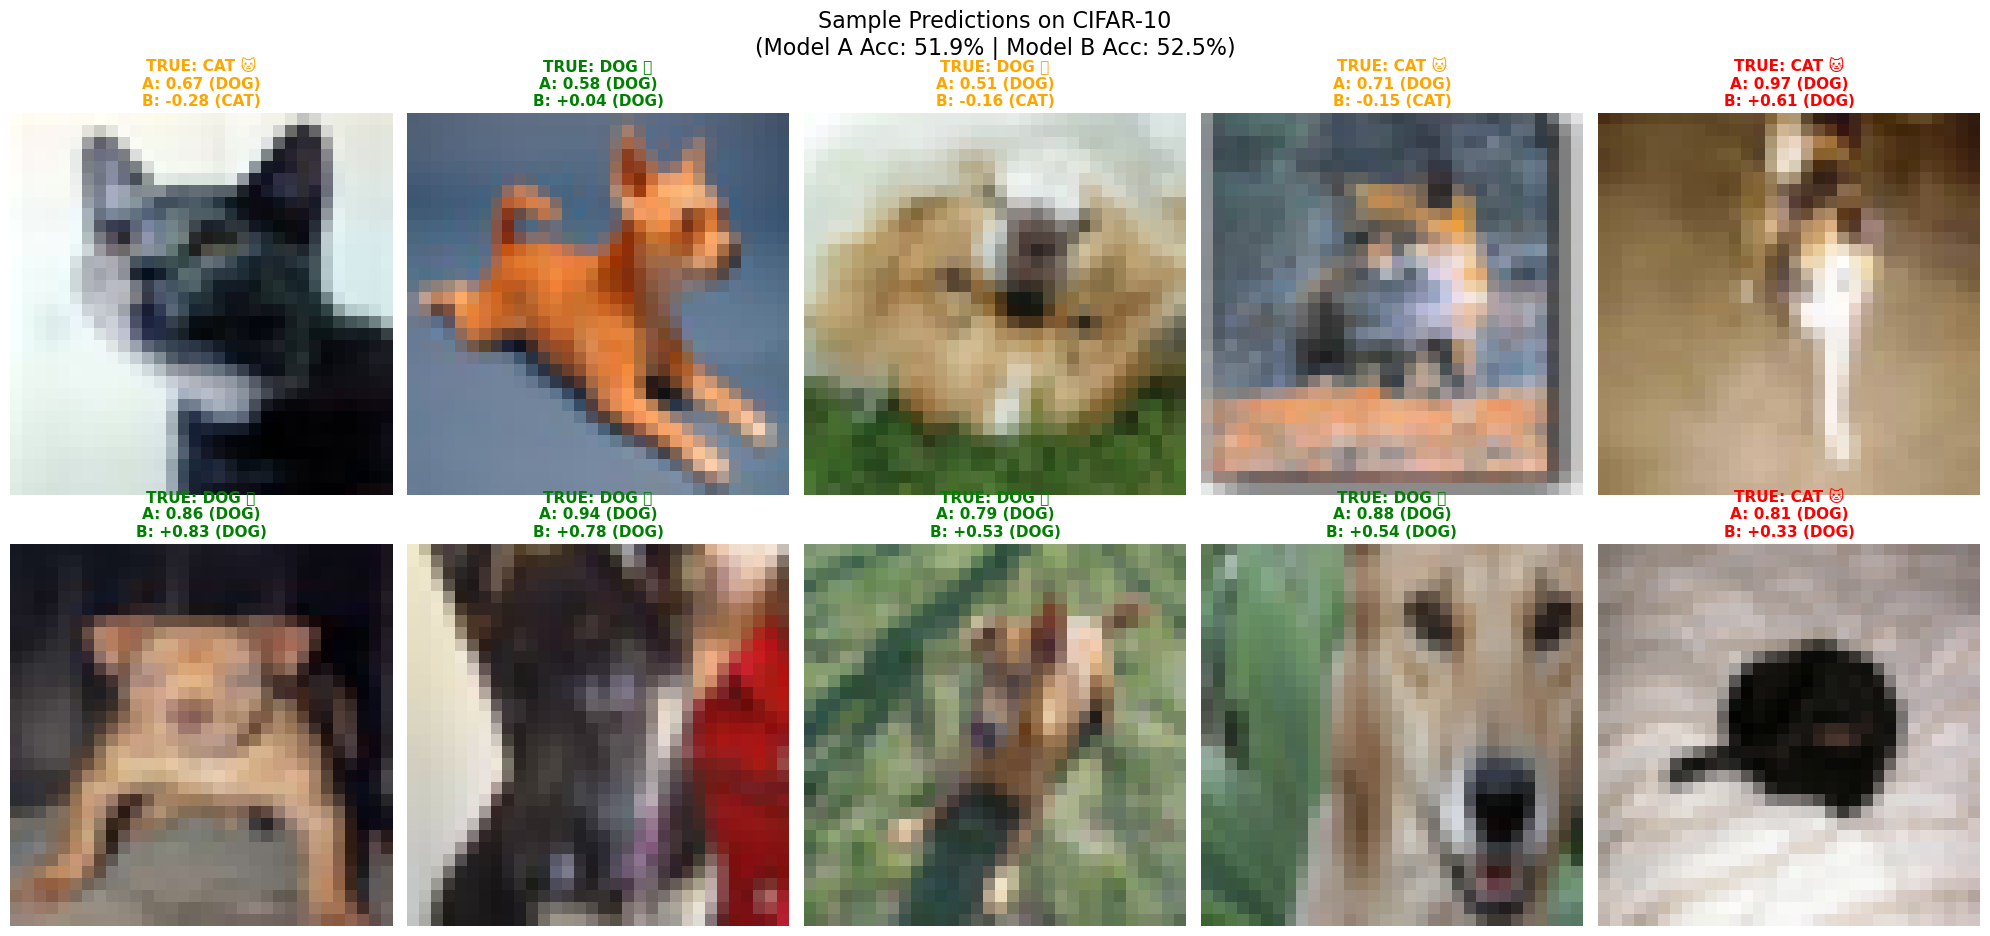

In [16]:
# Get a batch of 10 random images
images, labels = next(iter(vis_loader))
images = images.to(device)

# Run Inference
with torch.no_grad():
    out_A = model_A(images)
    out_B = model_B(images)

# Visualization
fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

for i in range(10):
    ax = axes[i]
    
    # Image preparation (Un-normalize for display)
    # RGB Images: permute(1, 2, 0) is needed to change (3, 32, 32) -> (32, 32, 3)
    img = images[i].cpu().permute(1, 2, 0) * 0.5 + 0.5
    ax.imshow(img)
    ax.axis('off')
    
    # CIFAR Labels: 3=Cat, 5=Dog
    true_label = "DOG 🐶" if labels[i] == 5 else "CAT 🐱"
    
    # --- Model A Logic ---
    val_A = out_A[i].item()
    pred_A = "DOG" if val_A > 0.5 else "CAT"
    
    # --- Model B Logic ---
    val_B = out_B[i].item()
    pred_B = "DOG" if val_B > 0.0 else "CAT"
    
    # Set Title
    title_text = f"TRUE: {true_label}\n" \
                 f"A: {val_A:.2f} ({pred_A})\n" \
                 f"B: {val_B:+.2f} ({pred_B})"
    
    # Color Logic: Green if both correct, Red if any wrong
    is_correct_A = (pred_A in true_label)
    is_correct_B = (pred_B in true_label)
    
    if is_correct_A and is_correct_B:
        color = 'green'
    elif not is_correct_A and not is_correct_B:
        color = 'red'
    else:
        color = 'orange' # One is right, one is wrong
    
    ax.set_title(title_text, color=color, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.suptitle(f"Sample Predictions on CIFAR-10\n(Model A Acc: {acc_A:.1f}% | Model B Acc: {acc_B:.1f}%)", fontsize=16, y=1.05)
plt.show()